In [7]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# 用户评分矩阵
user_item_matrix = np.array([
[2, 0, 10, 1, 10, 6, 3],
[3, 4, 5, 9, 6, 4, 10],
[0, 2, 7, 6, 9, 4, 3],
[8, 1, 1, 2, 7, 9, 9],
[8, 2, 7, 10, 9, 0, 1],
[7, 1, 0, 4, 0, 2, 1],
[5, 9, 3, 3, 10, 6, 10],
[8, 5, 5, 6, 4, 4, 1],
[7, 4, 2, 5, 1, 0, 3],
[2, 7, 4, 3, 4, 3, 4],
[0, 9, 4, 1, 6, 5, 4],
# [6, 0, 10, 9, 2, 5, 8],
# [5, 4, 3, 4, 1, 5, 10],
# [4, 7, 0, 4, 5, 2, 10],
# [1, 10, 3, 10, 9, 1, 8],
# [1, 8, 1, 9, 3, 7, 9],
# [2, 0, 8, 8, 8, 7, 5],
# [4, 2, 7, 1, 0, 6, 9],
# [9, 1, 6, 0, 8, 8, 3],
# [10, 1, 9, 10, 7, 0, 7],
# [8, 2, 5, 7, 0, 3, 7],
# [8, 2, 0, 5, 3, 6, 6],
# [0, 2, 7, 6, 8, 4, 3],
# [7, 5, 6, 2, 0, 3, 5],
# [4, 6, 8, 3, 5, 9, 0],
# [8, 1, 4, 5, 1, 2, 0],
# [3, 7, 4, 4, 4, 5, 1],
# [6, 0, 6, 4, 0, 10, 7],
# [8, 9, 10, 10, 0, 1, 0],
# [0, 7, 2, 7, 5, 5, 3],
# [6, 8, 3, 7, 10, 4, 7],
# [2, 9, 6, 1, 7, 1, 6],
# [9, 3, 1, 9, 2, 1, 0],
# [8, 6, 7, 5, 5, 2, 3],
# [1, 10, 1, 0, 1, 5, 6],
# [6, 5, 1, 6, 6, 7, 7],
# [9, 7, 6, 7, 1, 4, 9],
# [4, 5, 5, 0, 0, 10, 6],
# [7, 7, 6, 1, 7, 6, 10],
# [7, 1, 9, 6, 8, 7, 6],
# [7, 1, 4, 9, 1, 7, 0],
# [4, 7, 2, 2, 10, 10, 1],
# [2, 4, 4, 1, 5, 1, 4],
# [10, 3, 6, 2, 4, 5, 7],
# [1, 1, 2, 4, 7, 10, 9],
# [3, 6, 5, 10, 3, 1, 3],
# [6, 8, 5, 3, 4, 8, 6],
# [4, 4, 1, 0, 9, 2, 1],
# [8, 8, 0, 3, 2, 10, 8],
# [3, 6, 7, 0, 2, 10, 0],
# [9, 0, 3, 8, 6, 2, 4],
# [7, 9, 8, 10, 1, 5, 9],
# [1, 8, 2, 0, 0, 9, 9],
# [6, 4, 4, 9, 0, 2, 8],
# [0, 2, 8, 5, 4, 2, 5],
# [7, 3, 0, 6, 8, 10, 4],
# [5, 8, 4, 1, 3, 8, 7],
# [6, 8, 6, 4, 7, 9, 9],
# [8, 3, 10, 2, 6, 0, 5],
# [4, 0, 2, 5, 4, 0, 7],
# [9, 1, 8, 5, 3, 5, 5],
# [3, 6, 4, 8, 0, 2, 3],
# [5, 2, 8, 6, 10, 4, 5],
# [2, 0, 7, 4, 1, 4, 4],
# [7, 3, 10, 4, 7, 1, 4],
# [0, 1, 5, 3, 5, 3, 8],
# [5, 2, 5, 0, 3, 1, 8],
# [10, 4, 5, 2, 5, 1, 0],
# [0, 6, 2, 7, 2, 1, 7],
# [2, 0, 2, 4, 10, 6, 8],
# [7, 6, 6, 1, 1, 6, 9],
# [5, 0, 6, 8, 2, 7, 4],
# [2, 8, 10, 2, 6, 3, 3],
# [5, 3, 6, 2, 3, 7, 8],
# [5, 7, 7, 8, 3, 9, 3],
# [3, 0, 0, 8, 6, 5, 1],
# [9, 0, 10, 2, 7, 6, 7],
# [1, 8, 1, 10, 2, 7, 4],
# [10, 8, 5, 8, 9, 10, 4],
# [3, 6, 2, 9, 7, 3, 0],
# [9, 8, 2, 4, 5, 5, 10],
# [2, 9, 1, 10, 0, 0, 1],
# [4, 8, 9, 10, 0, 4, 1],
# [4, 9, 9, 2, 0, 10, 9],
# [9, 7, 8, 9, 10, 10, 2],
# [6, 10, 9, 10, 6, 8, 5],
# [6, 7, 6, 4, 1, 7, 9],
# [8, 2, 0, 5, 9, 3, 0],
# [4, 7, 0, 0, 9, 7, 10],
# [9, 2, 1, 7, 7, 2, 8],
# [9, 6, 8, 7, 8, 7, 2],
# [8, 3, 6, 9, 9, 7, 1],
# [6, 8, 1, 2, 8, 10, 8],
# [4, 6, 0, 5, 2, 2, 6],
# [4, 0, 2, 4, 6, 7, 1],
# [4, 6, 1, 8, 8, 3, 3],
# [5, 8, 5, 3, 4, 6, 1],
# [6, 6, 0, 6, 3, 3, 1],
# [0, 5, 8, 5, 3, 0, 3],
# [8, 1, 8, 4, 10, 2, 4],
# [10, 8, 2, 9, 8, 3, 10],
# [0, 3, 4, 6, 5, 8, 3],
# [9, 2, 1, 1, 3, 1, 4],
# [0, 8, 3, 6, 2, 2, 1],
# [10, 3, 7, 4, 1, 2, 6],
# [10, 0, 9, 3, 6, 5, 6],
# [4, 8, 1, 4, 4, 6, 1],
# [5, 0, 8, 6, 8, 1, 5],
# [0, 6, 1, 1, 4, 0, 0],
# [0, 7, 8, 3, 3, 8, 5],
# [5, 7, 7, 9, 9, 5, 1],
# [0, 9, 3, 0, 0, 7, 5],
# [2, 3, 6, 6, 7, 0, 2],
# [2, 2, 3, 10, 1, 1, 2],
# [1, 4, 10, 6, 3, 5, 3],
# [5, 1, 7, 4, 7, 1, 8],
# [8, 7, 7, 8, 10, 7, 10],
# [4, 3, 5, 10, 4, 0, 6],
# [2, 4, 6, 8, 0, 5, 6],
# [5, 0, 10, 9, 4, 8, 7],
# [6, 9, 9, 3, 6, 10, 10],
# [5, 1, 7, 7, 1, 7, 3],
# [3, 4, 3, 6, 4, 4, 5],
# [3, 6, 5, 10, 1, 1, 8],
# [2, 4, 1, 5, 10, 2, 2],
# [6, 10, 7, 1, 10, 3, 8],
# [3, 7, 9, 1, 9, 0, 5],
# [7, 5, 1, 4, 3, 2, 8],
# [0, 4, 1, 1, 10, 10, 10],
# [5, 4, 1, 10, 1, 4, 5],
# [5, 5, 1, 1, 6, 6, 10],
# [4, 7, 10, 2, 3, 6, 10],
# [4, 0, 6, 2, 7, 0, 10],
# [5, 2, 9, 6, 0, 5, 0],
# [5, 5, 2, 8, 3, 8, 8],
# [9, 2, 4, 7, 5, 2, 8],
# [7, 7, 9, 0, 9, 0, 10],
# [4, 1, 7, 2, 5, 0, 0],
# [3, 2, 3, 9, 1, 9, 1],
# [5, 3, 3, 8, 1, 0, 10],
# [8, 3, 3, 6, 6, 9, 1],
# [7, 6, 0, 4, 7, 8, 3],
# [2, 7, 1, 6, 4, 9, 6],
# [2, 0, 1, 4, 3, 2, 8],
# [0, 3, 10, 4, 4, 8, 0],
# [0, 7, 10, 7, 9, 3, 10],
# [1, 7, 8, 6, 4, 6, 10],
# [2, 1, 4, 5, 3, 6, 9],
# [6, 0, 6, 5, 4, 0, 8],
# [2, 9, 9, 1, 0, 2, 6],
# [1, 9, 10, 9, 10, 3, 8],
# [1, 6, 7, 6, 1, 4, 0],
# [2, 9, 4, 3, 3, 3, 6],
# [9, 4, 3, 4, 6, 4, 6],
# [2, 7, 4, 1, 2, 7, 5],
# [2, 1, 2, 7, 9, 1, 9],
# [4, 7, 5, 8, 0, 1, 3],
# [6, 10, 4, 7, 2, 9, 10],
# [3, 1, 7, 6, 2, 7, 1],
# [3, 0, 9, 4, 5, 6, 3],
# [8, 10, 4, 6, 4, 10, 7],
# [0, 10, 6, 6, 1, 9, 0],
# [3, 9, 10, 4, 1, 8, 9],
# [1, 0, 0, 2, 7, 5, 6],
# [6, 2, 2, 2, 0, 2, 4],
# [0, 4, 4, 6, 3, 7, 10],
# [3, 6, 10, 7, 4, 7, 1],
# [8, 10, 10, 4, 10, 2, 7],
# [4, 9, 4, 7, 2, 3, 5],
# [6, 0, 9, 5, 6, 10, 4],
# [9, 1, 4, 8, 1, 0, 6],
# [1, 1, 2, 0, 9, 7, 3],
# [7, 0, 6, 2, 2, 0, 5],
# [6, 10, 4, 0, 1, 0, 7],
# [1, 7, 6, 3, 8, 6, 6],
# [3, 1, 6, 1, 6, 2, 0],
# [5, 0, 10, 2, 2, 0, 2],
# [1, 8, 6, 0, 3, 5, 6],
# [4, 10, 10, 10, 7, 2, 6],
# [8, 10, 2, 7, 6, 5, 0],
# [8, 7, 3, 1, 4, 8, 3],
# [9, 9, 1, 1, 5, 5, 1],
# [4, 9, 7, 2, 10, 2, 1],
# [7, 8, 4, 10, 3, 9, 0],
# [10, 8, 5, 7, 3, 7, 2],
# [1, 7, 3, 4, 4, 5, 10],
# [10, 5, 4, 1, 3, 0, 0],
# [5, 5, 1, 0, 0, 5, 3],
# [7, 8, 2, 9, 8, 10, 1],
# [8, 7, 1, 6, 4, 4, 4],
# [8, 6, 5, 0, 6, 6, 8],
# [10, 1, 8, 9, 5, 9, 1],
# [5, 9, 1, 1, 10, 8, 0],
# [10, 8, 1, 7, 8, 7, 10],
# [8, 9, 1, 2, 10, 2, 2],
# [6, 0, 8, 0, 6, 8, 2],
# [9, 1, 9, 0, 4, 1, 8],
# [2, 6, 9, 2, 8, 4, 6],
# [3, 2, 1, 5, 0, 4, 9],
# [9, 10, 4, 1, 4, 5, 0],

])

# 计算 Pearson 相关系数的函数
def pearson_similarity(matrix):
    num_users = matrix.shape[0]
    similarity_matrix = np.zeros((num_users, num_users))

    for i in range(num_users):
        for j in range(i + 1, num_users):  # 只计算一半，因为矩阵是对称的
            user_i = matrix[i]
            user_j = matrix[j]

            mean_i = np.mean(user_i)
            mean_j = np.mean(user_j)

            numerator = np.sum((user_i - mean_i) * (user_j - mean_j))
            denominator = np.sqrt(np.sum((user_i - mean_i) ** 2) * np.sum((user_j - mean_j) ** 2))

            if denominator == 0:
                similarity = 0
            else:
                similarity = numerator / denominator

            # 填充到亲密关系矩阵并确保矩阵对称
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity

    # 对结果矩阵中的元素四舍五入到两位小数
    similarity_matrix = np.round(similarity_matrix, 2)

    return similarity_matrix


# 计算并打印亲密关系矩阵
similarity_matrix = pearson_similarity(user_item_matrix)
print(similarity_matrix)

#（任务相关性+u*夏普利值）*similarity

user_competence = np.full((user_item_matrix.shape[0]), 0)  # 初始信誉设为 0



# 读取任务相关性
#text_task_completion_data = pd.read_csv("D:\plus\\任务相关性.csv", header=None, names=['对象', '文本任务得分'])
task_relation_data = pd.read_csv("D:\plus\sha\任务相关性.csv", header=None, names=['对象', '任务相关性'])
task_relation_data['任务相关性'] = task_relation_data['任务相关性'].str.extract('(\d+\.\d+)').astype(float)
print(task_relation_data)

# 读取夏普利值数据
shape_values = pd.read_csv("D:\plus\sha\夏普利值.csv", header=None, names=['对象', '夏普利值'])
shape_values['夏普利值'] = shape_values['夏普利值'].str.extract('(\d+\.\d)').astype(float)

print(shape_values)
task_completion_data = pd.merge(task_relation_data, shape_values, on='对象')

task_completion_data['总完成度'] = task_completion_data['夏普利值'] + task_completion_data['任务相关性']

print(task_completion_data)
# 删除包含NaN值的行
task_completion_data.dropna(inplace=True)
print(f"task_completion_data{task_completion_data}")











# 计算用户信誉值
user_reputation = np.zeros(user_item_matrix.shape[0])
print(f"task_completion_data shape: {task_completion_data.shape}")
print(f"user_item_matrix shape: {user_item_matrix.shape}")

for i in range(min(user_item_matrix.shape[0], len(task_completion_data))):
    for j in range(min(user_item_matrix.shape[0], len(task_completion_data))):
        if i != j:
            if similarity_matrix[i, j] < 0:
                if not pd.isna(task_completion_data.iloc[i]['总完成度']):
                    user_reputation[i] = task_completion_data.iloc[i]['总完成度']
            else:
                if not pd.isna(task_completion_data.iloc[i]['总完成度']) and not pd.isna(
                        task_completion_data.iloc[j]['总完成度']):
                    user_reputation[i] += similarity_matrix[i, j] * task_completion_data.iloc[j]['总完成度']

total_reputation = np.sum(user_reputation)

print(f"total_reputation: {total_reputation}")


# 创建图
G = nx.Graph()

for i in range(user_item_matrix.shape[0]):
  G.add_node(i+1, reputation=user_reputation[i])

for i in range(user_item_matrix.shape[0]):
  for j in range(i+1, user_item_matrix.shape[0]):
      weight = round(similarity_matrix[i, j], 2)
      if weight > 0:
          G.add_edge(i+1, j+1, weight=weight)
#
# import numpy as np
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# import matplotlib.pyplot as plt
#
# def elbow_method(features, max_k):
#   # 标准化特征
#   scaler = StandardScaler()
#   features_scaled = scaler.fit_transform(features)
#
#   wcss = []
#   for k in range(1, max_k+1):
#       kmeans = KMeans(n_clusters=k, random_state=42)
#       kmeans.fit(features_scaled)
#       wcss.append(kmeans.inertia_)
#
#   # 绘制肘部图
#   plt.figure(figsize=(10, 6))
#   plt.plot(range(1, max_k+1), wcss, marker='o')
#   plt.title('Elbow Method')
#   plt.xlabel('Number of clusters')
#   plt.ylabel('WCSS')
#   plt.show()
#
# # 准备数据
# features = np.column_stack((
#   user_reputation,
#   np.mean(similarity_matrix, axis=1)
# ))
#
# # 运行肘部法则
# elbow_method(features, max_k=10)
#
# def identify_core_users_kmeans(user_reputation, similarity_matrix, n_clusters):
#   # 准备数据
#   features = np.column_stack((
#       user_reputation,
#       np.mean(similarity_matrix, axis=1)
#   ))
#
#   # 标准化特征
#   scaler = StandardScaler()
#   features_scaled = scaler.fit_transform(features)
#
#   # 应用K-means聚类
#   kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#   cluster_labels = kmeans.fit_predict(features_scaled)
#
#   # 找出具有最高平均信誉值的簇
#   cluster_avg_reputation = [np.mean(user_reputation[cluster_labels == i]) for i in range(n_clusters)]
#   core_cluster = np.argmax(cluster_avg_reputation)
#
#   # 识别核心用户
#   core_users = np.where(cluster_labels == core_cluster)[0]
#
#   return core_users, cluster_labels
#
# # 根据肘部图选择最佳簇数（这里需要您根据图形手动选择）
# best_n_clusters = 1  # 这个值需要根据肘部图来确定
#
# # 使用最佳簇数进行聚类
# core_users, cluster_labels = identify_core_users_kmeans(user_reputation, similarity_matrix, best_n_clusters)
#
# print("核心用户:")
# for user_index in core_users:
#   print(f"用户 {user_index + 1} - 信誉值: {user_reputation[user_index]}")
#
# # 计算核心用户的平均信誉值
# core_avg_reputation = np.mean(user_reputation[core_users])
# print(f"\n核心用户的平均信誉值: {core_avg_reputation}")
#
# # 识别亲密用户（第二高信誉值的簇）
# cluster_avg_reputation = [np.mean(user_reputation[cluster_labels == i]) for i in range(best_n_clusters)]
# second_best_cluster = np.argsort(cluster_avg_reputation)[-2]
# neighboring_users = np.where(cluster_labels == second_best_cluster)[0]
#
# print("\n亲密用户:")
# for user_index in neighboring_users:
#   print(f"用户 {user_index + 1} - 信誉值: {user_reputation[user_index]}")
#
# # 计算各组用户的统计信息
# other_users = set(range(len(user_reputation))) - set(core_users) - set(neighboring_users)
#
# print(f"\n核心用户数量: {len(core_users)}")
# print(f"亲密用户数量: {len(neighboring_users)}")
# print(f"其他用户数量: {len(other_users)}")
#
# print(f"\n核心用户的总信誉值: {np.sum(user_reputation[core_users])}")
# print(f"亲密用户的总信誉值: {np.sum(user_reputation[neighboring_users])}")
# print(f"其他用户的总信誉值: {np.sum(user_reputation[list(other_users)])}")
#
#
#
#
#















































































#源代码
# 找到信誉值最高的用户
core_user_index = np.argmax(user_reputation)
core_user_reputation = user_reputation[core_user_index]

# 找到信誉值高于65%的核心用户
condition = 0.65 * core_user_reputation
core_users = [i for i, reputation in enumerate(user_reputation) if reputation >= condition]
if core_user_index not in core_users:
  core_users.append(core_user_index)

print("信誉值高于65%的核心用户:")
for user_index in core_users:
  print(f"用户 {user_index + 1} - 信誉值: {user_reputation[user_index]}")

# 找到与核心用户群相邻且权重大于0.3的其他用户
threshold_weight = 0.3
neighboring_users = []

for user_index, similarities in enumerate(similarity_matrix):
  if user_index not in core_users:
      for core_user_index in core_users:
          if similarities[core_user_index] > threshold_weight:
              neighboring_users.append(user_index)

neighboring_users = list(set(neighboring_users))

print("与核心用户群相邻且权重大于0.3的其他用户:")
for user_index in neighboring_users:
  print(f"用户 {user_index + 1}")

# 设置节点颜色
node_colors = ['yellow' if i not in core_users and i not in neighboring_users else 'blue' if i in neighboring_users else 'red' for i in range(user_item_matrix.shape[0])]

print("统计亲密用户的人数: " + str(len(neighboring_users)))
print("统计核心用户的人数: " + str(len(core_users)))
print("第二层亲密关系用户: " + str(user_item_matrix.shape[0] - len(neighboring_users) - len(core_users)))

# 计算核心用户和亲密用户的信誉值
core_users_reputation = [user_reputation[user_index] for user_index in core_users]
neighboring_users_reputation = [user_reputation[user_index] for user_index in neighboring_users]

print("核心用户的信誉值:")
for user_index, reputation in zip(core_users, core_users_reputation):
  print(f"用户 {user_index + 1} - 信誉值: {reputation}")

print("\n亲密用户的信誉值:")
for user_index, reputation in zip(neighboring_users, neighboring_users_reputation):
  print(f"用户 {user_index + 1} - 信誉值: {reputation}")

other_users_reputation = [user_reputation[user_index] for user_index in range(user_item_matrix.shape[0]) if user_index not in core_users and user_index not in neighboring_users]

print("\n其他用户的信誉值:")
for user_index, reputation in enumerate(other_users_reputation, start=1):
  print(f"用户 {user_index} - 信誉值: {reputation}")

total_other_reputation = sum(other_users_reputation)
print("其他用户的总信誉值:", total_other_reputation)

total_core_reputation = sum(core_users_reputation)
total_neighboring_reputation = sum(neighboring_users_reputation)

print("\n核心用户的总信誉值:", total_core_reputation)
print("亲密用户的总信誉值:", total_neighboring_reputation)

[[ 0.   -0.13  0.74  0.1   0.19 -0.56 -0.02 -0.22 -0.71 -0.16  0.14]
 [-0.13  0.    0.31  0.04  0.06 -0.22  0.15 -0.59 -0.02 -0.05 -0.18]
 [ 0.74  0.31  0.   -0.24  0.43 -0.62 -0.05 -0.25 -0.61  0.01  0.17]
 [ 0.1   0.04 -0.24  0.   -0.33  0.22  0.41 -0.32 -0.19 -0.53 -0.22]
 [ 0.19  0.06  0.43 -0.33  0.    0.31 -0.44  0.59  0.39 -0.38 -0.52]
 [-0.56 -0.22 -0.62  0.22  0.31  0.   -0.43  0.71  0.78 -0.62 -0.76]
 [-0.02  0.15 -0.05  0.41 -0.44 -0.43  0.   -0.62 -0.28  0.5   0.63]
 [-0.22 -0.59 -0.25 -0.32  0.59  0.71 -0.62  0.    0.62 -0.31 -0.46]
 [-0.71 -0.02 -0.61 -0.19  0.39  0.78 -0.28  0.62  0.   -0.17 -0.55]
 [-0.16 -0.05  0.01 -0.53 -0.38 -0.62  0.5  -0.31 -0.17  0.    0.88]
 [ 0.14 -0.18  0.17 -0.22 -0.52 -0.76  0.63 -0.46 -0.55  0.88  0.  ]]
        对象       任务相关性
0       对象         NaN
1      对象1  117.319723
2      对象2  206.561306
3      对象3  264.874345
4      对象4  229.940686
..     ...         ...
196  对象196  191.537159
197  对象197  157.938774
198  对象198   19.049173
199  对象199

D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

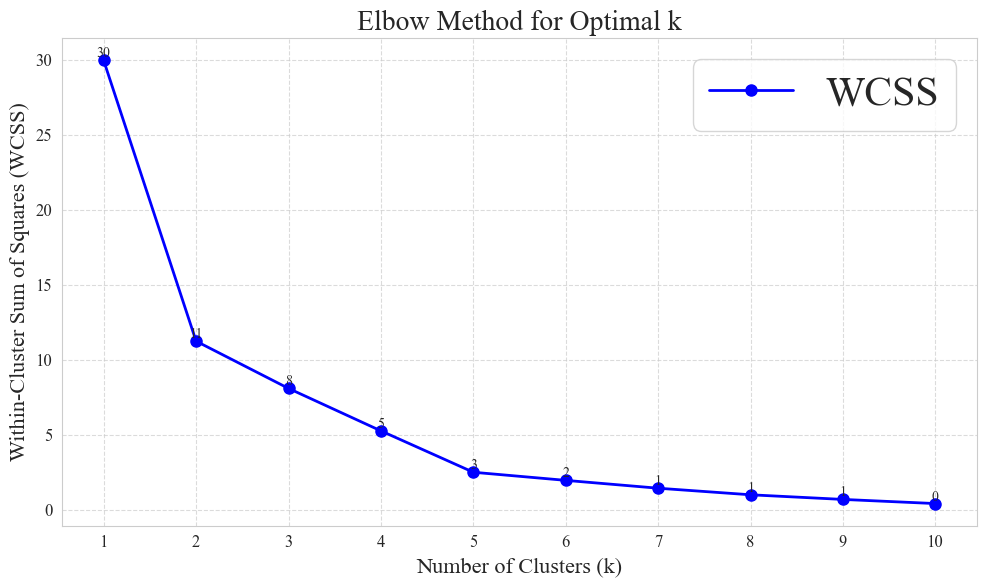

In [14]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

def elbow_method(features, max_k):
  # 标准化特征
  scaler = StandardScaler()
  features_scaled = scaler.fit_transform(features)

  wcss = []
  for k in range(1, max_k+1):
      kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
      kmeans.fit(features_scaled)
      wcss.append(kmeans.inertia_)

  # 创建Roman字体
  roman_font = FontProperties(family='serif', style='normal')

  # 绘制肘部图
  plt.figure(figsize=(10, 6))
  plt.plot(range(1, max_k+1), wcss, marker='o', linestyle='-', linewidth=2, markersize=8, color='blue')
  plt.title('Elbow Method for Optimal k', fontsize=20, fontproperties=roman_font)
  plt.xlabel('Number of Clusters (k)', fontsize=16, fontproperties=roman_font)
  plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=16, fontproperties=roman_font)
  plt.xticks(range(1, max_k+1), fontsize=12, fontproperties=roman_font)
  plt.yticks(fontsize=12, fontproperties=roman_font)
  plt.grid(True, linestyle='--', alpha=0.7)

  # 添加数据标签
  for i, val in enumerate(wcss):
      plt.text(i+1, val, f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontproperties=roman_font)

  # 添加图例
  legend_font = FontProperties(family='serif', style='normal', size=30)
  plt.legend(['WCSS'], loc='upper right', prop=legend_font)

  plt.tight_layout()
  plt.savefig('elbow_method.pdf', format='pdf', bbox_inches='tight')
  plt.show()

# 准备数据
features = np.column_stack((
  user_reputation,
  np.mean(similarity_matrix, axis=1)
))

# 运行肘部法则
elbow_method(features, max_k=10)

D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


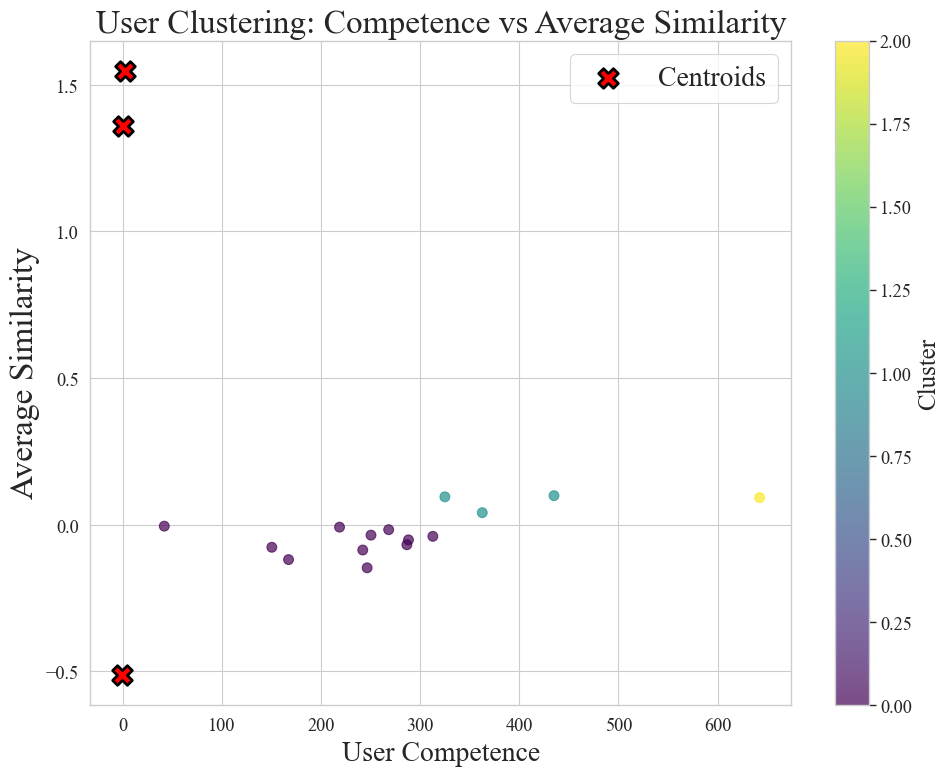

Cluster 0: 11 users (73.33%)
Cluster 1: 3 users (20.00%)
Cluster 2: 1 users (6.67%)

Core users cluster: 2
Number of core users: 1

Cluster 0:
  Average competence: 224.9762
  Average similarity: -0.0592

Cluster 1:
  Average competence: 374.3112
  Average similarity: 0.0787

Cluster 2:
  Average competence: 642.4360
  Average similarity: 0.0927


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

def plot_2d_clusters_for_paper(features, labels, title):
  plt.figure(figsize=(10, 8))
  sns.set_style("whitegrid")
  sns.set_context("paper", font_scale=1.5)

  # Set the font to Times New Roman
  rcParams['font.family'] = 'serif'
  rcParams['font.serif'] = ['Times New Roman']

  # Create scatter plot
  scatter = plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='viridis', alpha=0.7, s=50)

  plt.xlabel('User Competence', fontsize=20)
  plt.ylabel('Average Similarity', fontsize=24)
  plt.title(title, fontsize=24)

  # Add colorbar
  cbar = plt.colorbar(scatter)
  cbar.set_label('Cluster', fontsize=18)

  # Add cluster centroids
  centroids = kmeans.cluster_centers_
  plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, linewidths=2, edgecolors='black', label='Centroids')

  plt.legend(fontsize=20, loc='upper right')
  plt.tight_layout()

  # Save high-quality images
  plt.savefig('2d_cluster_plot_paper.png', dpi=300, bbox_inches='tight')
  plt.savefig('2d_cluster_plot_paper.pdf', format='pdf', bbox_inches='tight')
  plt.show()

# The rest of your code remains unchanged

# 准备数据
features = np.column_stack((
    user_reputation,
    np.mean(similarity_matrix, axis=1)
))

# 标准化特征
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 应用K-means聚类
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

# 绘制2D聚类图
plot_2d_clusters_for_paper(features, cluster_labels, 'User Clustering: Competence vs Average Similarity')

# 打印每个簇的用户数量和百分比
total_users = len(user_reputation)
for i in range(n_clusters):
    cluster_size = np.sum(cluster_labels == i)
    percentage = (cluster_size / total_users) * 100
    print(f"Cluster {i}: {cluster_size} users ({percentage:.2f}%)")

# 找出具有最高平均能力值的簇
cluster_avg_competence = [np.mean(user_reputation[cluster_labels == i]) for i in range(n_clusters)]
core_cluster = np.argmax(cluster_avg_competence)

print(f"\nCore users cluster: {core_cluster}")
print(f"Number of core users: {np.sum(cluster_labels == core_cluster)}")

# 计算并打印每个簇的平均能力值和平均相似度
for i in range(n_clusters):
    cluster_users = np.where(cluster_labels == i)[0]
    avg_competence = np.mean(user_reputation[cluster_users])
    avg_similarity = np.mean([np.mean(similarity_matrix[j]) for j in cluster_users])
    print(f"\nCluster {i}:")
    print(f"  Average competence: {avg_competence:.4f}")
    print(f"  Average similarity: {avg_similarity:.4f}")

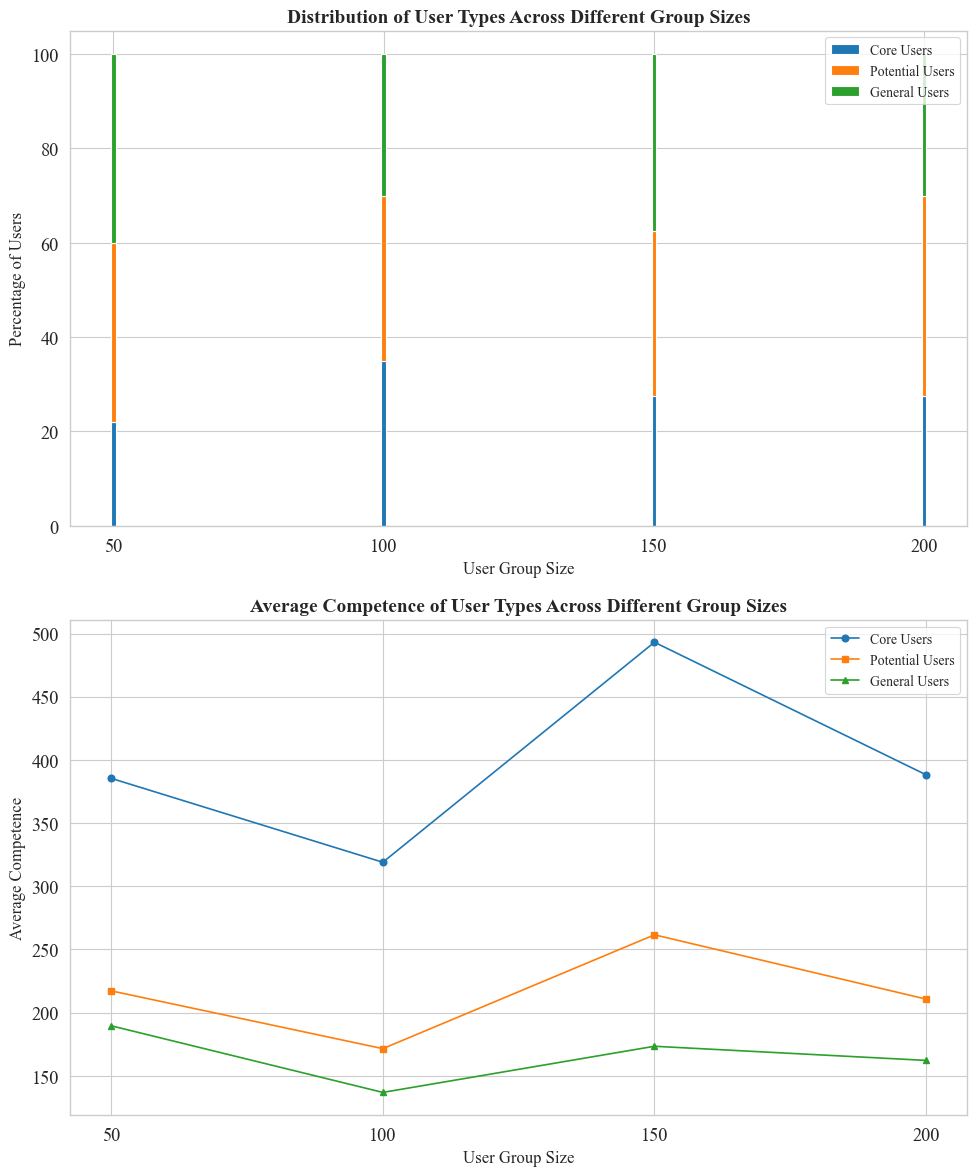

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
group_sizes = [200, 150, 100, 50]
core_percentages = [27.50, 27.52, 35.00, 22.00]
potential_percentages = [42.50, 34.90, 35.00, 38.00]
general_percentages = [30.00, 37.58, 30.00, 40.00]

core_competence = [388.1934, 493.0929, 318.9631, 385.3750]
potential_competence = [210.6757, 261.5574, 171.4644, 217.1938]
general_competence = [162.1505, 173.3432, 136.8252, 189.5453]

# 创建图表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
plt.subplots_adjust(hspace=0.3)

# 用户比例堆叠柱状图
ax1.bar(group_sizes, core_percentages, label='Core Users', color='#1f77b4')
ax1.bar(group_sizes, potential_percentages, bottom=core_percentages, label='Potential Users', color='#ff7f0e')
ax1.bar(group_sizes, general_percentages, bottom=np.array(core_percentages)+np.array(potential_percentages), label='General Users', color='#2ca02c')

ax1.set_xlabel('User Group Size', fontsize=12)
ax1.set_ylabel('Percentage of Users', fontsize=12)
ax1.set_title('Distribution of User Types Across Different Group Sizes', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.set_xticks(group_sizes)
ax1.set_xticklabels(group_sizes)

# 平均能力值折线图
ax2.plot(group_sizes, core_competence, marker='o', label='Core Users', color='#1f77b4')
ax2.plot(group_sizes, potential_competence, marker='s', label='Potential Users', color='#ff7f0e')
ax2.plot(group_sizes, general_competence, marker='^', label='General Users', color='#2ca02c')

ax2.set_xlabel('User Group Size', fontsize=12)
ax2.set_ylabel('Average Competence', fontsize=12)
ax2.set_title('Average Competence of User Types Across Different Group Sizes', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.set_xticks(group_sizes)
ax2.set_xticklabels(group_sizes)

# 调整布局并保存图片
plt.tight_layout()
plt.savefig('user_distribution_and_competence_improved.png', dpi=300, bbox_inches='tight')
plt.savefig('user_distribution_and_competence_improved.pdf', format='pdf', bbox_inches='tight')
plt.show()




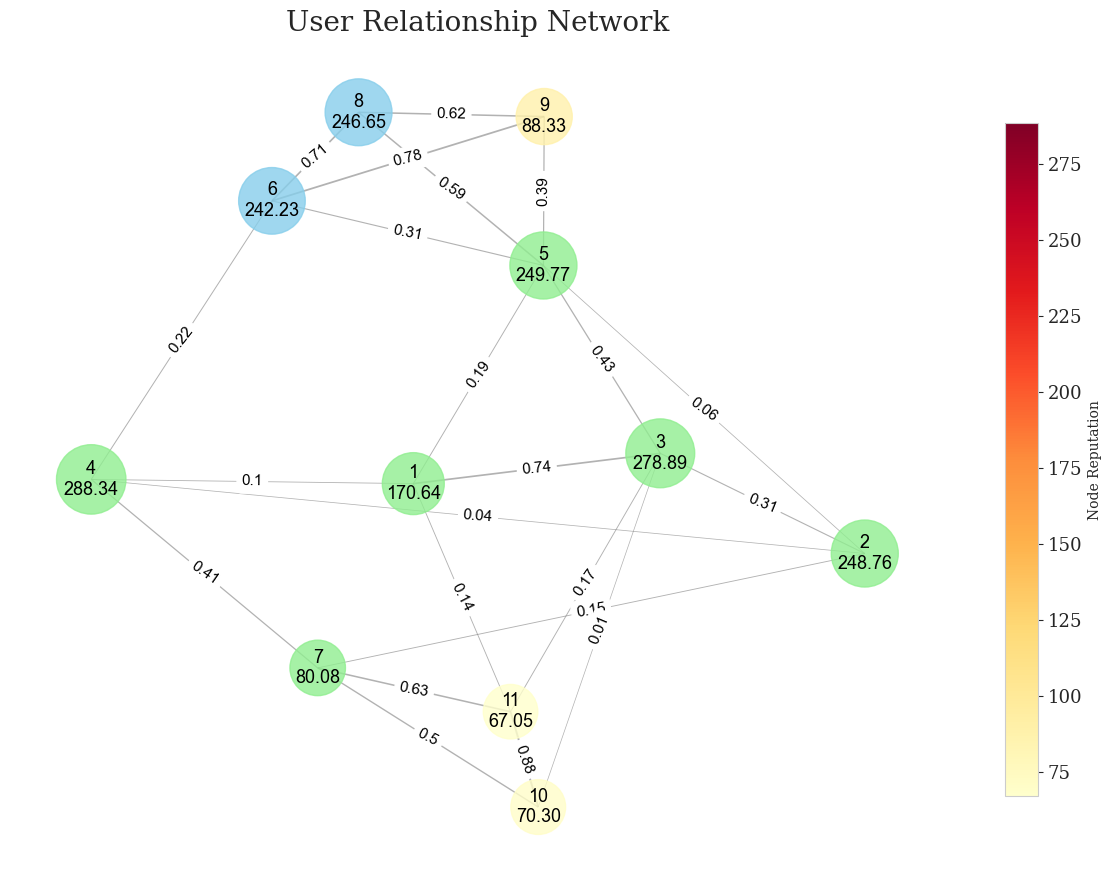

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 假设 G, user_reputation, core_users, neighboring_users 等变量已经定义

# 获取节点数量
num_nodes = G.number_of_nodes()

# 动态调整节点大小和图形大小
base_node_size = 2500 if num_nodes < 50 else 1000 if num_nodes < 100 else 200
figure_size = (12, 9) if num_nodes < 50 else (16, 12) if num_nodes < 100 else (20, 15)

# 设置颜色映射
color_map = plt.cm.YlOrRd
norm = mcolors.Normalize(vmin=min(user_reputation), vmax=max(user_reputation))

# 设置节点颜色和大小
node_colors = [color_map(norm(rep)) if i+1 not in core_users and i+1 not in neighboring_users
               else 'skyblue' if i+1 in neighboring_users
               else 'lightgreen' for i, rep in enumerate(user_reputation)]
node_sizes = [base_node_size * (0.5 + 0.5 * (rep / max(user_reputation))) for rep in user_reputation]

# 设置边的颜色和宽度
edge_colors = ['gray' for _ in G.edges()]
edge_widths = [0.5 + G[u][v]['weight'] for u, v in G.edges()]

# 设置字体为罗马字体
plt.rcParams['font.family'] = 'serif'

# 创建图形
plt.figure(figsize=figure_size)

# 动态调整布局
k_value = 0.5 if num_nodes < 50 else 0.3 if num_nodes < 100 else 0.2
seed_value = 2  # 固定随机种子
pos = nx.spring_layout(G, k=k_value, iterations=50, seed=seed_value)  # 添加 seed 参数

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.6)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)

# 添加节点标签（包括节点编号和权重）
font_size = 13 if num_nodes < 50 else 8 if num_nodes < 100 else 6
labels = {node: f"{node}\n{user_reputation[node-1]:.2f}" for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=font_size)

# 添加边的权重标签
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=font_size-2)

# 添加图例
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, label="Node Reputation", shrink=0.8)
cbar.ax.tick_params(labelsize=font_size)

# 添加标题和说明
plt.title("User Relationship Network", fontsize=20)
# plt.text(0.05, 0.05, "Node color: Green = Core, Blue = Neighboring, Gradient = Others\n"
#                      "Node size and label: Proportional to user reputation\n"
#                      "Edge width and label: Proportional to similarity",
#          transform=plt.gca().transAxes, fontsize=10, verticalalignment="bottom")

plt.axis('off')
plt.tight_layout()
plt.show()


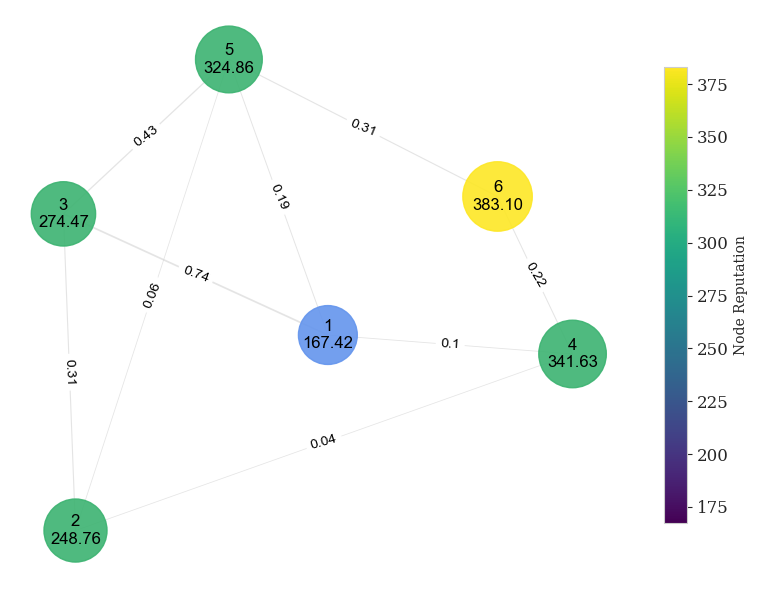

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 假设 G, user_reputation, core_users, neighboring_users 等变量已经定义

# 固定随机种子以确保布局一致
seed = 16
np.random.seed(seed)

# 获取节点数量
num_nodes = G.number_of_nodes()

# 动态调整节点大小和图形大小
base_node_size = 2500 if num_nodes < 50 else 1500 if num_nodes < 100 else 200
figure_size = (8, 6) if num_nodes < 50 else (10, 8) if num_nodes < 100 else (12, 9)

# 设置颜色映射
color_map = plt.cm.viridis
norm = mcolors.Normalize(vmin=min(user_reputation), vmax=max(user_reputation))

# 设置节点颜色和大小
node_colors = [color_map(norm(rep)) if i+1 not in core_users and i+1 not in neighboring_users
               else 'cornflowerblue' if i+1 in neighboring_users
               else 'mediumseagreen' for i, rep in enumerate(user_reputation)]
node_sizes = [base_node_size * (0.5 + 0.5 * (rep / max(user_reputation))) for rep in user_reputation]

# 设置边的颜色和宽度
edge_colors = ['lightgray' for _ in G.edges()]
edge_widths = [0.5 + G[u][v]['weight'] for u, v in G.edges()]

# 设置字体为罗马字体
plt.rcParams['font.family'] = 'serif'

# 创建图形
plt.figure(figsize=figure_size)

# 动态调整布局
k_value = 0.2 if num_nodes < 50 else 0.15 if num_nodes < 100 else 0.1
pos = nx.spring_layout(G, k=k_value, iterations=50, seed=seed)

# 对核心用户的位置进行轻微调整，使其更靠近中心，但不完全重叠
for core_user in core_users:
    pos[core_user] = pos[core_user] * 0.5 + 0.25 * np.random.randn(2)

# 手动调整节点 6 的位置
pos[6] = pos[6] * 0.1

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.6)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)

# 添加节点标签（包括节点编号和权重）
font_size = 12 if num_nodes < 50 else 11 if num_nodes < 100 else 10  # 增大字体大小
nx.draw_networkx_labels(G, pos, labels, font_size=font_size)  # 取消字体加粗

# 添加边的权重标签
edge_label_font_size = 10 if num_nodes < 50 else 9 if num_nodes < 100 else 8
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=edge_label_font_size)

# 添加图例
sm = plt.cm.ScalarMappable(cmap=color_map, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, label="Node Reputation", shrink=0.8)
cbar.ax.tick_params(labelsize=font_size)

plt.axis('off')
plt.tight_layout()

# 保存为PDF文件
plt.savefig("user_relationship_network.pdf", format="pdf")

plt.show()


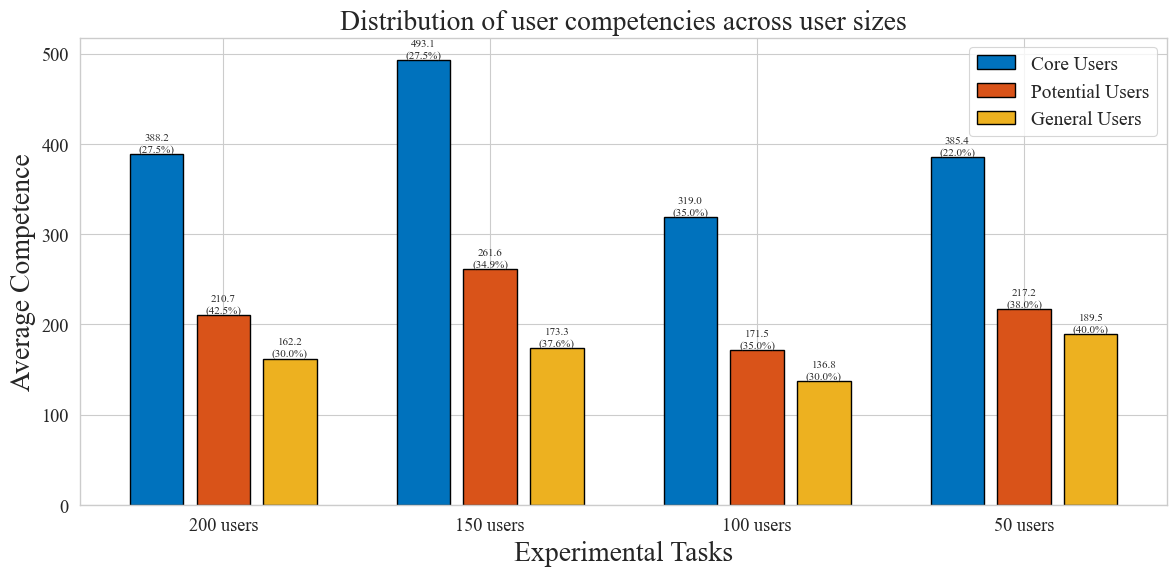

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Data
tasks = ['200 users', '150 users', '100 users', '50 users']
core_users = [388.1934, 493.0929, 318.9631, 385.3750]
potential_users = [210.6757, 261.5574, 171.4644, 217.1938]
general_users = [162.1505, 173.3432, 136.8252, 189.5453]

core_percentages = [27.50, 27.52, 35.00, 22.00]
potential_percentages = [42.50, 34.90, 35.00, 38.00]
general_percentages = [30.00, 37.58, 30.00, 40.00]

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Set the width of each bar and the positions of the bars
width = 0.2  # Reduced from 0.25 to 0.2
x = np.arange(len(tasks))
spacing = 0.05  # New spacing between bars within a group

# Create the bars with new colors, black edges, and adjusted positions
rects1 = ax.bar(x - width - spacing, core_users, width, label='Core Users', color='#0072bd', edgecolor='black', linewidth=1)
rects2 = ax.bar(x, potential_users, width, label='Potential Users', color='#d95319', edgecolor='black', linewidth=1)
rects3 = ax.bar(x + width + spacing, general_users, width, label='General Users', color='#edb120', edgecolor='black', linewidth=1)

# Customize the plot
ax.set_ylabel('Average Competence', fontsize=20)
ax.set_xlabel('Experimental Tasks', fontsize=20)
ax.set_title('Distribution of user competencies across user sizes', fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(tasks)
ax.legend(fontsize=14)

# Add value labels on the bars
def autolabel(rects, percentages):
  for i, rect in enumerate(rects):
      height = rect.get_height()
      ax.text(rect.get_x() + rect.get_width()/2., height,
              f'{height:.1f}\n({percentages[i]:.1f}%)',
              ha='center', va='bottom', fontsize=8)

autolabel(rects1, core_percentages)
autolabel(rects2, potential_percentages)
autolabel(rects3, general_percentages)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('user_competencies_chart.pdf')
plt.show()

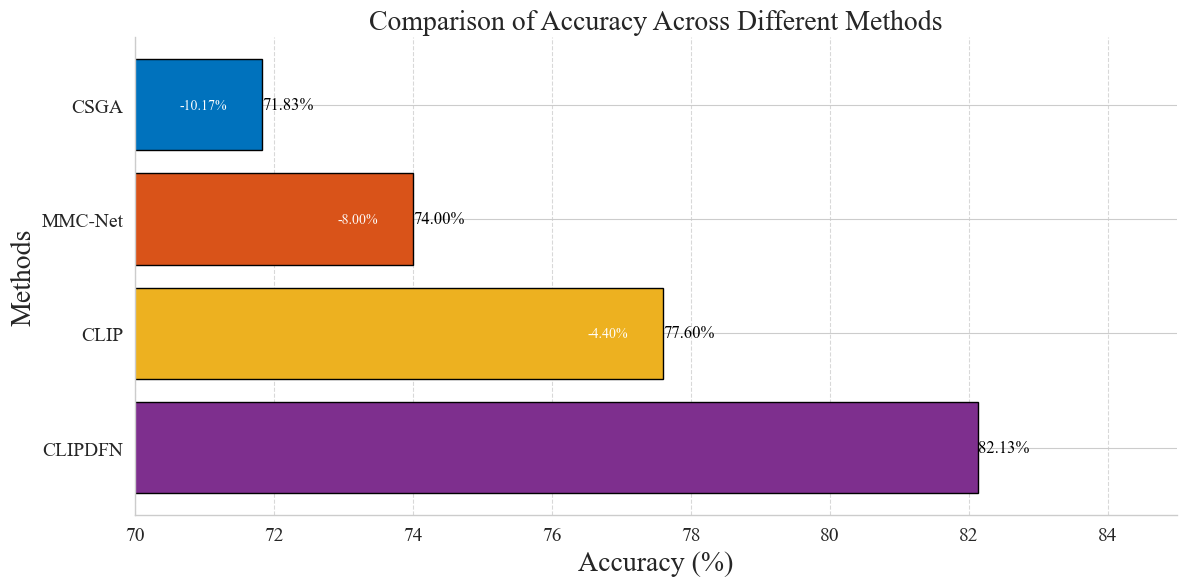

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
methods = ['CSGA', 'MMC-Net', 'CLIP', 'CLIP_DFN']
accuracies = [71.83, 74.00, 77.60, 82.13]

# 创建图形
fig, ax = plt.subplots(figsize=(12, 6))
# 设置背景为白色
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 使用新的颜色方案
colors = ['#0072bd', '#d95319', '#edb120', '#7e2f8e']

# 绘制水平条形图
bars = ax.barh(methods, accuracies, color=colors, edgecolor='black', linewidth=1)

# 添加数值标签
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}%',
            ha='left', va='center', fontsize=12, color='black')

    # 添加与最佳方法的差异
    if methods[i] != 'CLIPDFN':
        diff = 82.00 - width
        ax.text(width - 0.5, bar.get_y() + bar.get_height()/2, f'-{diff:.2f}%',
                ha='right', va='center', fontsize=10, color='white' )

# 设置标题和标签
ax.set_title('Comparison of Accuracy Across Different Methods', fontsize=20)
ax.set_xlabel('Accuracy (%)', fontsize=20)
ax.set_xlim(70, 85)  # 调整X轴范围以聚焦于实际数值
ax.set_ylabel('Methods', fontsize=20)

# 设置刻度标签大小
ax.tick_params(axis='both', which='major', labelsize=14)

# 移除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加网格线
ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='gray')

# 反转Y轴，使CLIPDFN在顶部
ax.invert_yaxis()

# 调整布局
plt.tight_layout()

# 保存图片
plt.savefig('accuracy_comparison_enhanced.pdf', dpi=300, bbox_inches='tight')

# 显示图片
plt.show()

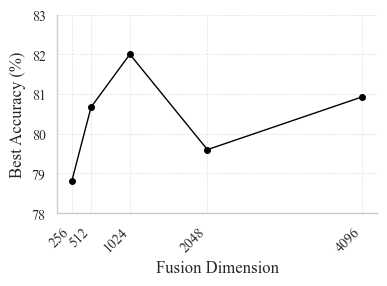

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
fusion_dimensions = [256, 512, 1024, 2048, 4096]
best_accuracies = [78.80, 80.67, 82.00, 79.60, 80.93]

# 设置全局字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (4, 3),  # 通常的单栏图大小
    'savefig.dpi': 300,
    'savefig.format': 'pdf'  # 很多期刊要求PDF格式
})

# 创建图表
fig, ax = plt.subplots()

# 绘制折线图
ax.plot(fusion_dimensions, best_accuracies, marker='o', color='black', linewidth=1, markersize=4)

# 设置轴标签
ax.set_xlabel('Fusion Dimension')
ax.set_ylabel('Best Accuracy (%)')

# 设置x轴刻度
ax.set_xticks(fusion_dimensions)
ax.set_xticklabels(fusion_dimensions, rotation=45, ha='right')

# 设置y轴范围，使数据点不会太靠近轴的顶部或底部
ax.set_ylim(78, 83)

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.7, which='major', color='lightgray', linewidth=0.5)

# 移除顶部和右侧的轴线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 调整布局
plt.tight_layout()

# 保存图表
plt.savefig('fusion_dimension_vs_accuracy.pdf', bbox_inches='tight')

# 显示图表
plt.show()

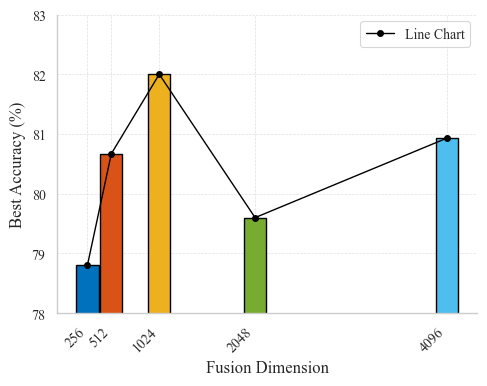

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
fusion_dimensions = [256, 512, 1024, 2048, 4096]
best_accuracies = [78.80, 80.67, 82.13, 79.60, 80.93]

# 设置全局字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (5, 4),  # 稍微调整尺寸以容纳更宽的条形图
    'savefig.dpi': 300,
    'savefig.format': 'pdf'  # 很多期刊要求PDF格式
})

# 创建图表
fig, ax = plt.subplots()

# 设置矩形宽度
bar_width = 238

# 绘制条形图，确保每个条形图颜色不同
colors = ['#0072bd', '#d95319', '#edb120', '#77ac30', '#4dbeee']
bars = ax.bar(fusion_dimensions, best_accuracies, color=colors, edgecolor='black', linewidth=1, width=bar_width)

# 在条形图上绘制折线图
ax.plot(fusion_dimensions, best_accuracies, marker='o', color='black', linewidth=1, markersize=4, linestyle='-', label='Line Chart')

# 设置轴标签
ax.set_xlabel('Fusion Dimension')
ax.set_ylabel('Best Accuracy (%)')

# 设置x轴刻度
ax.set_xticks(fusion_dimensions)
ax.set_xticklabels(fusion_dimensions, rotation=45, ha='right')

# 设置y轴范围，使数据点不会太靠近轴的顶部或底部
ax.set_ylim(78, 83)

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.7, which='major', color='lightgray', linewidth=0.5)

# 移除顶部和右侧的轴线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加图例
ax.legend()

# 调整布局
plt.tight_layout()

# 保存图表
plt.savefig('fusion_dimension_vs_accuracy_bar_line.pdf', bbox_inches='tight')

# 显示图表
plt.show()


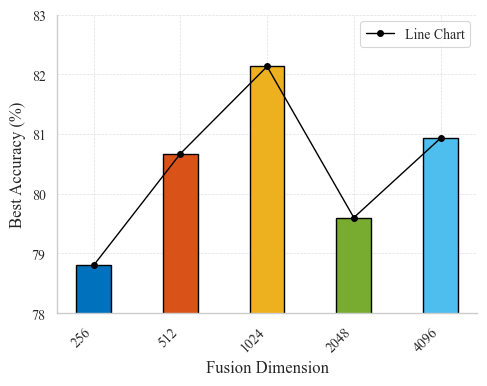

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
fusion_dimensions = [256, 512, 1024, 2048, 4096]
best_accuracies = [78.80, 80.67, 82.13, 79.60, 80.93]

# 设置全局字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (5, 4),  # 稍微调整尺寸以容纳更宽的条形图
    'savefig.dpi': 300,
    'savefig.format': 'pdf'  # 很多期刊要求PDF格式
})

# 设置矩形宽度和间隔
bar_width = 0.4
indices = np.arange(len(fusion_dimensions))

# 绘制条形图，确保每个条形图颜色不同
colors = ['#0072bd', '#d95319', '#edb120', '#77ac30', '#4dbeee']
bars = ax.bar(indices, best_accuracies, color=colors, edgecolor='black', linewidth=1, width=bar_width)

# 创建图表
fig, ax = plt.subplots()

# 绘制条形图
bars = ax.bar(indices, best_accuracies, color=colors, edgecolor='black', linewidth=1, width=bar_width)

# 在条形图上绘制折线图
ax.plot(indices, best_accuracies, marker='o', color='black', linewidth=1, markersize=4, linestyle='-', label='Line Chart')

# 设置轴标签
ax.set_xlabel('Fusion Dimension')
ax.set_ylabel('Best Accuracy (%)')

# 设置x轴刻度和标签
ax.set_xticks(indices)
ax.set_xticklabels(fusion_dimensions, rotation=45, ha='right')

# 设置y轴范围，使数据点不会太靠近轴的顶部或底部
ax.set_ylim(78, 83)

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.7, which='major', color='lightgray', linewidth=0.5)

# 移除顶部和右侧的轴线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加图例
ax.legend()

# 调整布局
plt.tight_layout()

# 保存图表
plt.savefig('fusion_dimension_vs_accuracy_bar_line.pdf', bbox_inches='tight')

# 显示图表
plt.show()


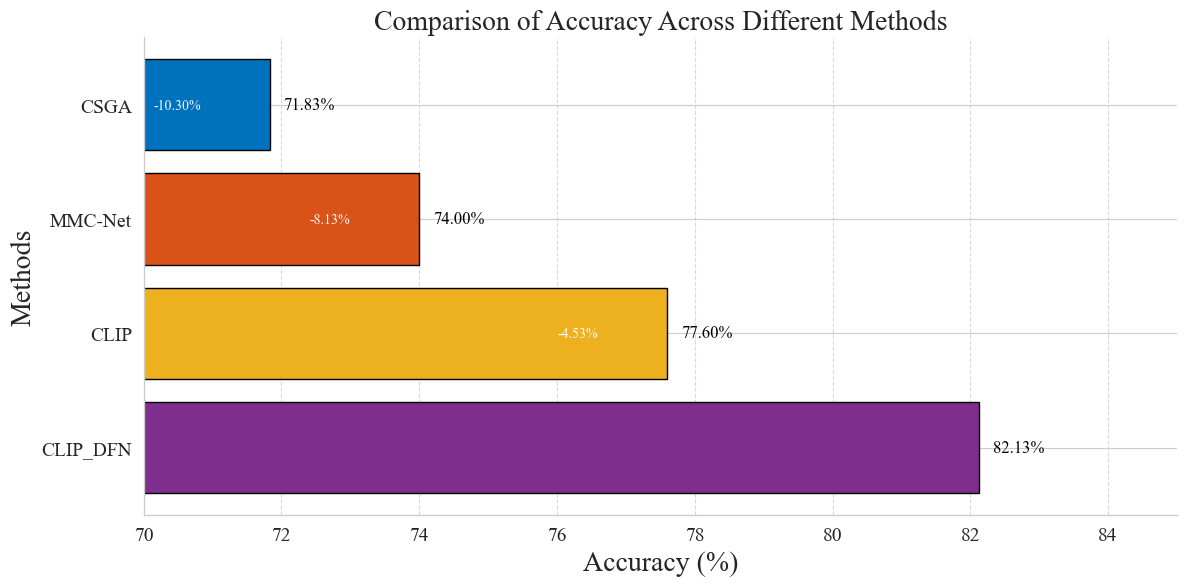

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
methods = ['CSGA', 'MMC-Net', 'CLIP', 'CLIP_DFN']
accuracies = [71.83, 74.00, 77.60, 82.13]

# 创建图形
fig, ax = plt.subplots(figsize=(12, 6))
# 设置背景为白色
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 使用新的颜色方案
colors = ['#0072bd', '#d95319', '#edb120', '#7e2f8e']

# 绘制水平条形图
bars = ax.barh(methods, accuracies, color=colors, edgecolor='black', linewidth=1)

# 添加数值标签
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{width:.2f}%',
            ha='left', va='center', fontsize=12, color='black')

    # 添加与最佳方法的差异
    if methods[i] != 'CLIP_DFN':
        diff = 82.13 - width
        ax.text(width - 1, bar.get_y() + bar.get_height()/2, f'-{diff:.2f}%',
                ha='right', va='center', fontsize=10, color='white')

# 设置标题和标签
ax.set_title('Comparison of Accuracy Across Different Methods', fontsize=20)
ax.set_xlabel('Accuracy (%)', fontsize=20)
ax.set_xlim(70, 85)  # 调整X轴范围以聚焦于实际数值
ax.set_ylabel('Methods', fontsize=20)

# 设置刻度标签大小
ax.tick_params(axis='both', which='major', labelsize=14)

# 移除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加网格线
ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='gray')

# 反转Y轴，使CLIP_DFN在顶部
ax.invert_yaxis()

# 调整布局
plt.tight_layout()

# 保存图片
plt.savefig('accuracy_comparison_enhanced.pdf', dpi=300, bbox_inches='tight')

# 显示图片
plt.show()
